In [3]:
import pandas as pd

# 1. Load Dataset
df = pd.read_csv("C:/Users/Yash Patel/OneDrive/Desktop/DA/Nassau Candy Distributor.csv")

In [28]:
# print first five rows 
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost
0,1,US-2021-103800-CHO-MIL-31000,03-01-2024,30-06-2026,Standard Class,103800,United States,Houston,Texas,77095,Chocolate,Interior,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28
1,2,US-2021-112326-CHO-TRI-54000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60
2,3,US-2021-112326-CHO-NUT-13000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00
3,4,US-2021-112326-CHO-SCR-58000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30
4,5,US-2021-141817-CHO-TRI-54000,05-01-2024,05-07-2026,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,Chocolate,Atlantic,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,11.25,3,7.35,3.90


In [29]:
# 2. Basic Info Check
print("Shape:", df.shape)
print("\nColumns:\n", df.columns)
print("\nInfo:")
print(df.info())

Shape: (10194, 18)

Columns:
 Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Country/Region', 'City', 'State/Province',
       'Postal Code', 'Division', 'Region', 'Product ID', 'Product Name',
       'Sales', 'Units', 'Gross Profit', 'Cost'],
      dtype='str')

Info:
<class 'pandas.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          10194 non-null  int64  
 1   Order ID        10194 non-null  str    
 2   Order Date      10194 non-null  str    
 3   Ship Date       10194 non-null  str    
 4   Ship Mode       10194 non-null  str    
 5   Customer ID     10194 non-null  int64  
 6   Country/Region  10194 non-null  str    
 7   City            10194 non-null  str    
 8   State/Province  10194 non-null  str    
 9   Postal Code     10194 non-null  str    
 10  Division        10194 non-null  str    
 1

In [ ]:
# find missing value
print("\nMissing Values:\n", df.isnull().sum())



Missing Values:
 Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Country/Region    0
City              0
State/Province    0
Postal Code       0
Division          0
Region            0
Product ID        0
Product Name      0
Sales             0
Units             0
Gross Profit      0
Cost              0
dtype: int64


In [33]:
# 3. Convert Dates (important step)
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True, errors='coerce')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True, errors='coerce')
# 4. Create Shipping Time (in days)
df['shipping_time'] = (df['Ship Date'] - df['Order Date']).dt.days


In [ ]:
# Remove invalid values
df = df[(df['shipping_time'] > 0) & (df['shipping_time'] < 30)]

In [ ]:

# Final Check
print("\nShipping Time Stats:\n", df['shipping_time'].describe())


Shipping Time Stats:
 count    10194.000000
mean         4.083284
std          2.209171
min          1.000000
25%          2.000000
50%          4.000000
75%          6.000000
max          7.000000
Name: shipping_time, dtype: float64


In [67]:
# 7. Remove duplicate columns (safety step)
df = df.loc[:, ~df.columns.duplicated()]

In [69]:
# 8. Save NEW file (avoid overwrite)
df.to_csv("C:/Users/Yash Patel/OneDrive/Desktop/DA/processed_data.csv", index=False)



In [4]:
# 9. Reload to verify
df_new = pd.read_csv("C:/Users/Yash Patel/OneDrive/Desktop/DA/processed_data.csv")

print("\nReloaded Data:")
print(df_new.head())

print("\nFinal Columns:\n", df_new.columns)


Reloaded Data:
   Row ID                      Order ID  Order Date   Ship Date  \
0       1  US-2021-103800-CHO-MIL-31000  2024-01-03  2026-06-30   
1       2  US-2021-112326-CHO-TRI-54000  2024-01-04  2026-07-01   
2       3  US-2021-112326-CHO-NUT-13000  2024-01-04  2026-07-01   
3       4  US-2021-112326-CHO-SCR-58000  2024-01-04  2026-07-01   
4       5  US-2021-141817-CHO-TRI-54000  2024-01-05  2026-07-05   

        Ship Mode  Customer ID Country/Region          City State/Province  \
0  Standard Class       103800  United States       Houston          Texas   
1  Standard Class       112326  United States    Naperville       Illinois   
2  Standard Class       112326  United States    Naperville       Illinois   
3  Standard Class       112326  United States    Naperville       Illinois   
4  Standard Class       141817  United States  Philadelphia   Pennsylvania   

  Postal Code   Division    Region     Product ID  \
0       77095  Chocolate  Interior  CHO-MIL-31000   
1     

<b style="font-size:30px">Shipping Time Distribution</b>

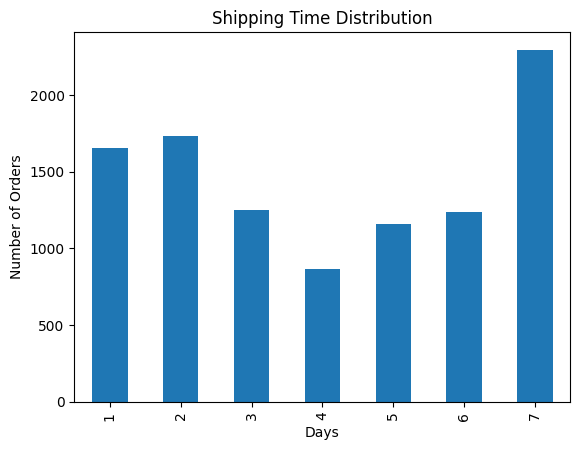

In [16]:
import matplotlib.pyplot as plt

df_new['shipping_time'].value_counts().sort_index().plot(kind='bar')
plt.title("Shipping Time Distribution")
plt.xlabel("Days")
plt.ylabel("Number of Orders")
plt.show()

<b style="font-size:30px;">Region Wise Analysis</b>

In [17]:

region_time = df_new.groupby('Region')['shipping_time'].mean()
print(region_time)

Region
Atlantic    4.149029
Gulf        3.988272
Interior    4.098073
Pacific     4.059637
Name: shipping_time, dtype: float64


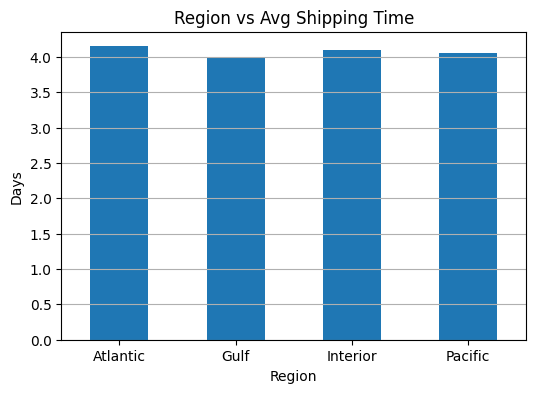

In [29]:
plt.figure(figsize=(6,4))
region_time.plot(kind='bar')
plt.title("Region vs Avg Shipping Time")
plt.ylabel("Days")
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.show()

<b style="font-size:30px;">Ship Mode Analysis</b>

In [19]:
ship_mode_time = df_new.groupby('Ship Mode')['shipping_time'].mean()
print(ship_mode_time)

Ship Mode
First Class       4.753876
Same Day          3.559415
Second Class      4.586660
Standard Class    3.797712
Name: shipping_time, dtype: float64


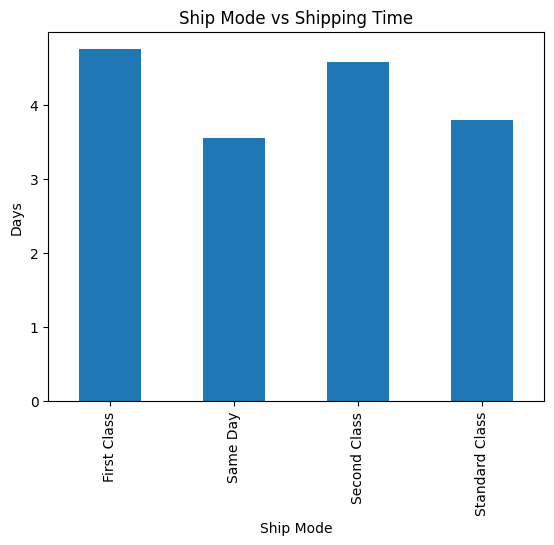

In [20]:
ship_mode_time.plot(kind='bar')
plt.title("Ship Mode vs Shipping Time")
plt.ylabel("Days")
plt.show()

<b style="font-size:30px">Profit Analysis</b>

In [21]:
profit_region = df_new.groupby('Region')['Gross Profit'].sum()
print(profit_region)

Region
Atlantic    26973.70
Gulf        14700.67
Interior    21282.49
Pacific     30485.94
Name: Gross Profit, dtype: float64


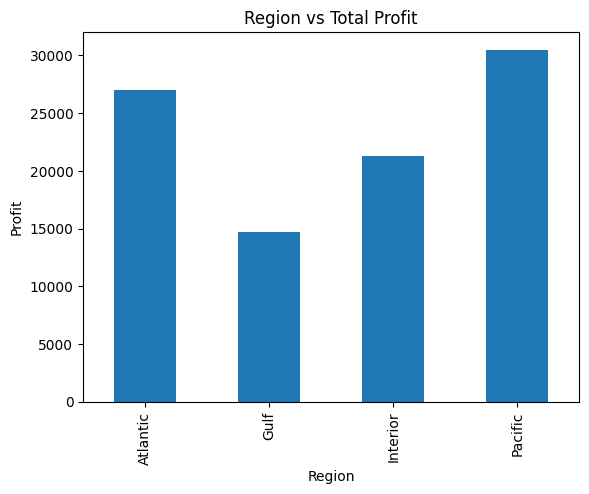

In [22]:
profit_region.plot(kind='bar')
plt.title("Region vs Total Profit")
plt.ylabel("Profit")
plt.show()

<b style="font-size:30px">Region vs Sales</b>

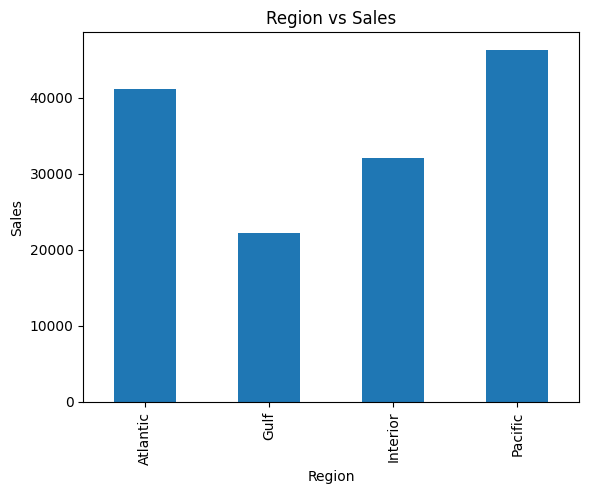

In [23]:
region_sales = df_new.groupby('Region')['Sales'].sum()

region_sales.plot(kind='bar')
plt.title("Region vs Sales")
plt.ylabel("Sales")
plt.show()


<b style="font-size:30px">Units vs Shipping Time</b>

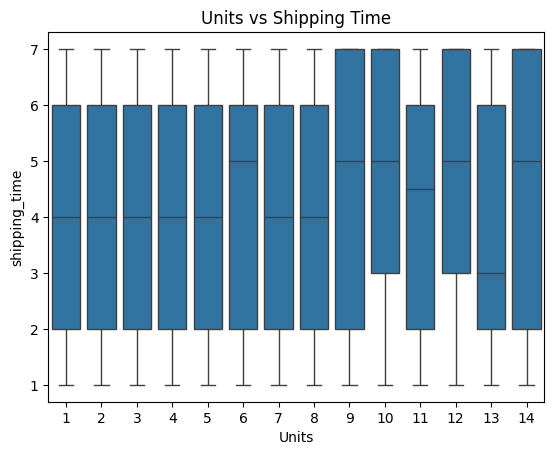

In [25]:
import seaborn as sns
sns.boxplot(x='Units', y='shipping_time', data=df_new)
plt.title("Units vs Shipping Time")
plt.show()